In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
df = pd.read_csv("../data/OnlineRetail.csv", encoding="ISO-8859-1")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
df=df.dropna(subset=['CustomerID'])

In [ ]:
df=df[df["Quantity"]>0]

In [ ]:
df = df[df["UnitPrice"]>0]

In [ ]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [ ]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

In [ ]:
df["Revenue"].sum()

np.float64(8911407.904)

In [ ]:
df["InvoiceNo"].nunique()

18532

In [ ]:
top_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
top_countries.head(10)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

Text(0, 0.5, 'Revenue')

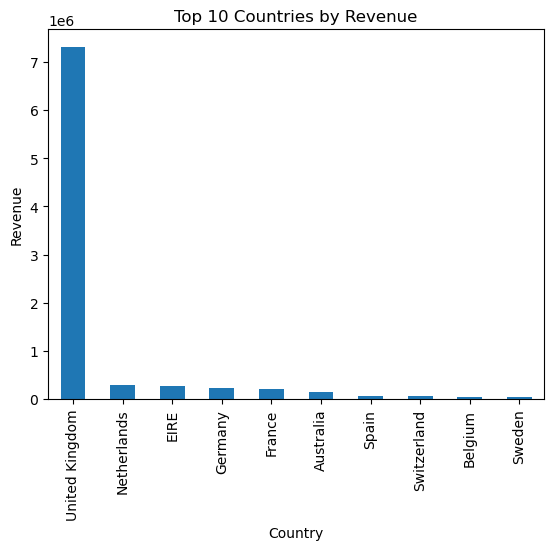

In [ ]:
top_10_countries = top_countries.head(10)
top_10_countries.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")


In [ ]:
df["invoice_date"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
df["Month"] = df["invoice_date"].dt.to_period("M")

In [ ]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

In [ ]:
monthly_revenue

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64

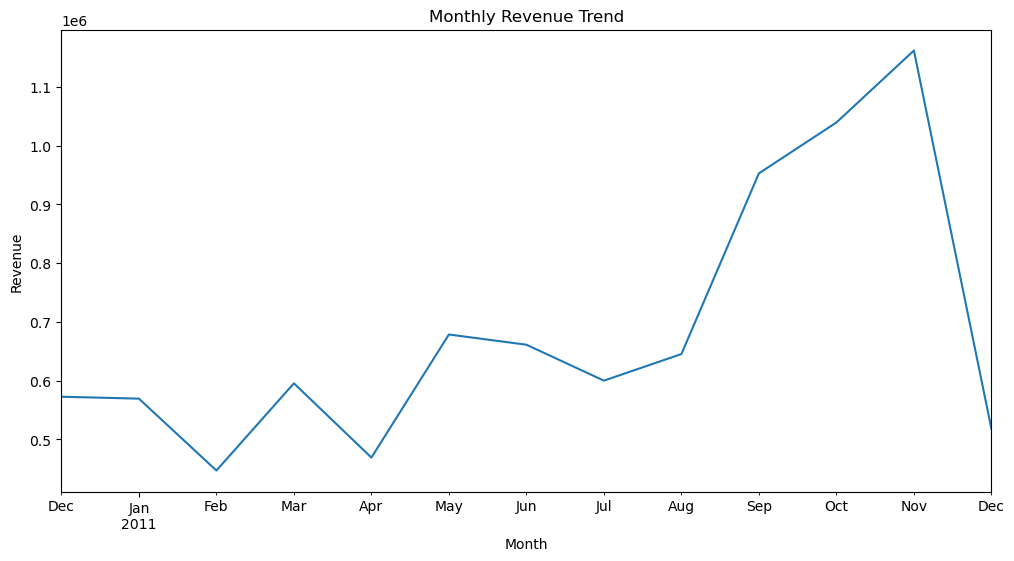

In [ ]:
plt.figure(figsize=(12, 6))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [ ]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)

In [ ]:
top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

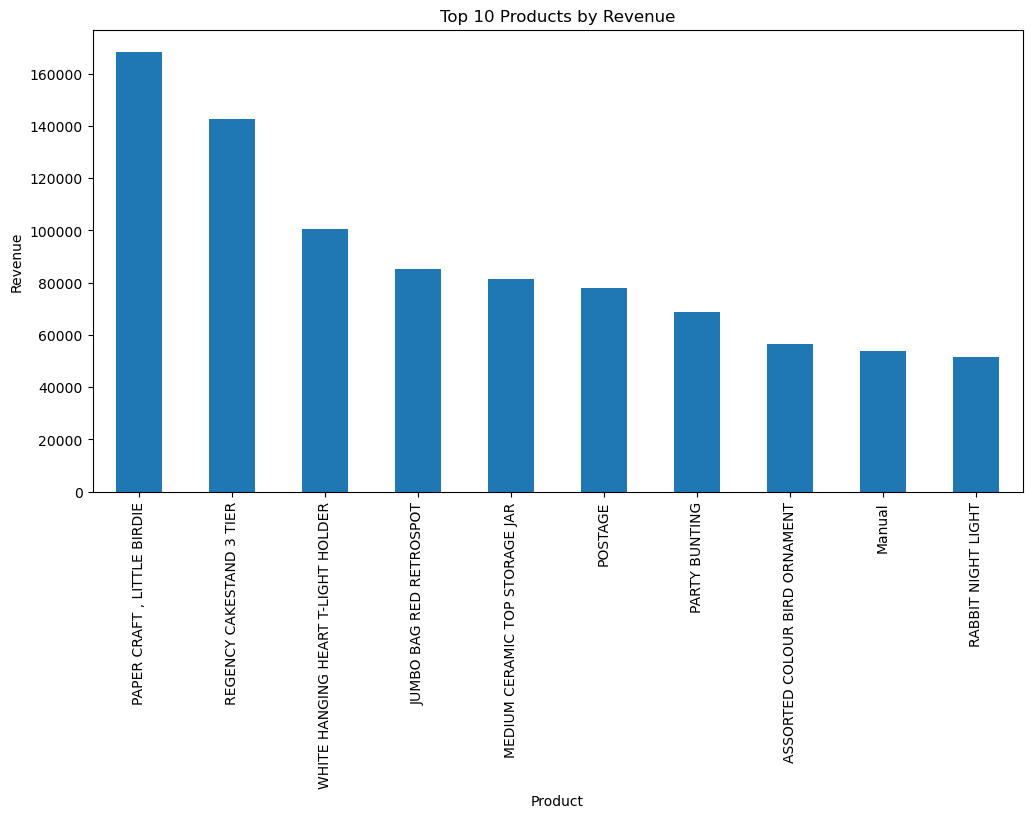

In [ ]:
top_10_products = top_products.head(10)
plt.figure(figsize=(12, 6))
top_10_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [ ]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)

In [ ]:
top_customers.head(10)


CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

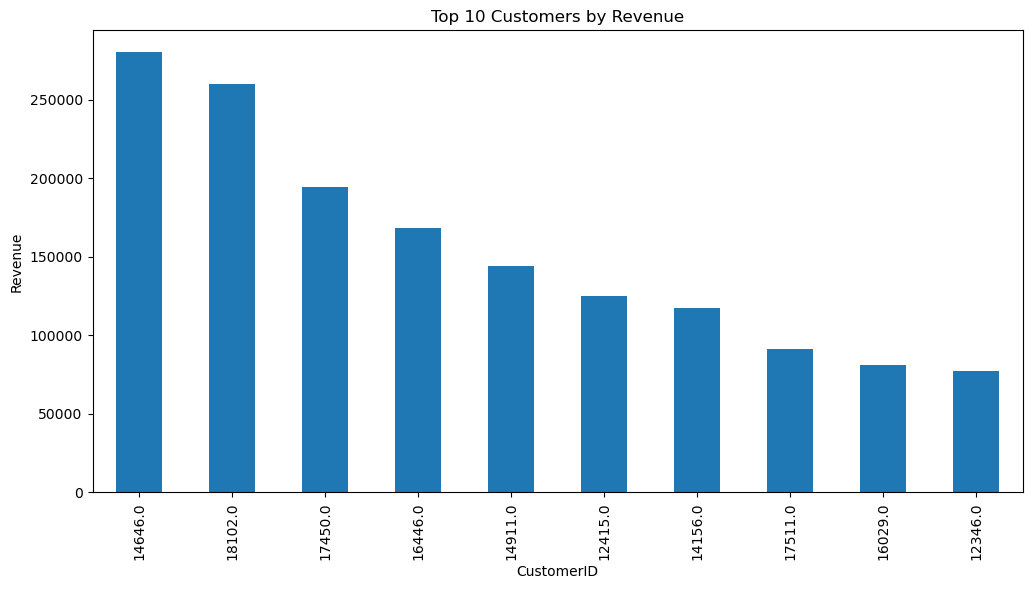

In [ ]:
top_10_customers = top_customers.head(10)
plt.figure(figsize=(12, 6))
top_10_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("CustomerID")
plt.ylabel("Revenue")
plt.show()

In [ ]:
df.to_csv("../data/cleaned_retail.csv", index=False)

In [ ]:
df["invoice_date"] = pd.to_datetime(df["InvoiceDate"])
df["customer_id"] = df["CustomerID"].astype(str)
df["month"] = df["invoice_date"].dt.strftime("%Y-%m")


In [ ]:
df.to_csv("../data/cleaned_retail.csv", index=False)

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Invoicedate"] = df["InvoiceDate"].dt.strftime("%Y-%m-%d %H:%M:%S")

In [ ]:
df.to_csv("../data/cleaned_retail.csv", index=False)

In [56]:
conn = sqlite3.connect("../data/retail.db")

In [60]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'invoice_date',
       'Month', 'customer_id', 'month', 'Invoicedate'],
      dtype='object')


In [72]:
df=df.drop(columns=['month'])

KeyError: "['month'] not found in axis"

In [73]:
df=df.drop(columns=['Invoicedate'])

In [69]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'invoice_date',
       'Month', 'customer_id', 'Invoicedate'],
      dtype='object')


In [75]:
df["Month"] = df["Month"].astype(str)

In [76]:
df.to_sql("retail", conn, if_exists="replace", index=False)

397884

In [77]:
query = """
SELECT *
FROM retail
limit 5
"""

In [78]:
test_df = pd.read_sql_query(query, conn)
test_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,invoice_date,Month,customer_id
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01 08:26:00,2010-12,17850.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,2010-12,17850.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01 08:26:00,2010-12,17850.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,2010-12,17850.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,2010-12,17850.0


In [85]:
with open("../sql/monthly_sales.sql", "r") as file:
    monthly_sales_query = pd.read_sql_query(file.read(), conn)
    print(monthly_sales_query)

      Month  TotalRevenue
0   2010-12    572713.890
1   2011-01    569445.040
2   2011-02    447137.350
3   2011-03    595500.760
4   2011-04    469200.361
5   2011-05    678594.560
6   2011-06    661213.690
7   2011-07    600091.011
8   2011-08    645343.900
9   2011-09    952838.382
10  2011-10   1039318.790
11  2011-11   1161817.380
12  2011-12    518192.790


In [88]:
with open("../sql/revenue_analysis.sql", "r") as file:
    revenue_analysis_query = pd.read_sql_query(file.read(), conn)
    print(revenue_analysis_query)

                 Country  TotalRevenue
0         United Kingdom   7308391.554
1            Netherlands    285446.340
2                   EIRE    265545.900
3                Germany    228867.140
4                 France    209024.050
5              Australia    138521.310
6                  Spain     61577.110
7            Switzerland     56443.950
8                Belgium     41196.340
9                 Sweden     38378.330
10                 Japan     37416.370
11                Norway     36165.440
12              Portugal     33439.890
13               Finland     22546.080
14             Singapore     21279.290
15       Channel Islands     20450.440
16               Denmark     18955.340
17                 Italy     17483.240
18                Cyprus     13590.380
19               Austria     10198.680
20                Poland      7334.650
21                Israel      7221.690
22                Greece      4760.520
23               Iceland      4310.000
24                Canada 

In [ ]:
with open("../sql/top_customers.sql", "r") as file:
    with open("../sql/top_customers.sql", "r") as file:
        sql = file.read().replace("FROM Sales", "FROM retail")
        top_customers_query = pd.read_sql_query(sql, conn)
        print(top_customers_query)
    print(top_customers_query)

DatabaseError: Execution failed on sql 'SELECT
        CustomerID,
        SUM(Revenue) as TotalRevenue
FROM Sales
GROUP BY CustomerID
ORDER BY TotalRevenue DESC
LIMIT 10;': no such table: Sales